## 0. Setup & Dependencies

In [6]:
# Install if needed (uncomment)
# !pip install wrds yfinance arch statsmodels scipy pandas numpy matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

# Color palette for 5 stocks
COLORS = {
    'Ubtech': '#1f77b4',
    'Dobot': '#ff7f0e',
    'Estun': '#2ca02c',
    'Tuopu': '#d62728',
    'Nabtesco': '#9467bd'
}

TICKERS = {
    'Ubtech': '9880.HK',
    'Dobot': '2432.HK',
    'Estun': '002747.SZ',
    'Tuopu': '601689.SH',
    'Nabtesco': '6268.T'
}

print('Setup complete.')

Setup complete.


## 1. Data Retrieval

**Option A: WRDS Compustat Global** (preferred — academic quality)  
**Option B: Yahoo Finance** (fallback — free, no login)  

Run ONE of the two cells below.

In [7]:
# ============================================================
# 테이블 이름 확인 (이걸 먼저 실행)
# ============================================================
import wrds
db = wrds.Connection()

# Compustat Global 관련 테이블 목록 확인
libs = db.list_libraries()
comp_libs = [l for l in libs if 'comp' in l.lower()]
print("Compustat libraries:", comp_libs)

# 정확한 테이블 확인
for lib in comp_libs:
    try:
        tables = db.list_tables(library=lib)
        g_tables = [t for t in tables if t.startswith('g_')]
        if g_tables:
            print(f"\n{lib}: {g_tables}")
    except:
        pass

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
Compustat libraries: ['audit_audit_comp', 'comp', 'comp_execucomp', 'comp_filings', 'comp_global_daily', 'comp_na_daily_all', 'comp_ph', 'comp_pit', 'comp_segments_hist_daily', 'comp_snapshot', 'comp_urq', 'comph', 'compsamp', 'compsamp_all', 'compsamp_snapshot', 'compseg', 'compsnap', 'execcomp', 'wrdsapps_link_comp_eushort']

comp: ['g_chars', 'g_co_aaudit', 'g_co_adesind', 'g_co_afnd1', 'g_co_afnd2', 'g_co_afnddc1', 'g_co_afnddc2', 'g_co_afntind1', 'g_co_afntind2', 'g_co_ainvval', 'g_co_gsuppl', 'g_co_hgic', 'g_co_iaudit', 'g_co_idesind', 'g_co_ifndq', 'g_co_ifndsa', 'g_co_ifndytd', 'g_co_ifntq', 'g_co_ifntsa', 'g_co_ifntytd', 'g_co_industry', 'g_co_ipcd', 'g_co_offtitl', 'g_company', 'g_currency', 'g_ecind_desc', 'g_ecind_mth', 'g_exrt_dly', 'g_exrt_mth', 'g_funda', 'g_funda_fncd', 'g_fundq',

In [8]:
# ============================================================
# Fix: wrds + sqlalchemy 호환 이슈 해결
# ============================================================
import wrds
db = wrds.Connection()

# 방법 1: params 명시적으로 None 전달
name_search = db.raw_sql(
    """
    SELECT DISTINCT gvkey, conm 
    FROM comp.g_company 
    WHERE conm ILIKE '%%estun%%' 
       OR conm ILIKE '%%ubtech%%' 
       OR conm ILIKE '%%dobot%%' 
       OR conm ILIKE '%%tuopu%%' 
       OR conm ILIKE '%%nabtesco%%'
    """,
    params={}
)
print(name_search)

WRDS recommends setting up a .pgpass file.
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
    gvkey                       conm
0  102849              NABTESCO CORP
1  294119      MAHALAXMI RUBTECH LTD
2  319394  NINGBO TUOPU GROUP CO LTD
3  319420    ESTUN AUTOMATION CO LTD
4  360014   UBTECH ROBOTICS CORP LTD
5  365358    SHENZHEN DOBOT CORP LTD


In [9]:
# ============================================================
# OPTION B: Yahoo Finance (fallback)
# ============================================================
import yfinance as yf

START = '2023-01-01'
END = '2026-02-28'

data = yf.download(
    list(TICKERS.values()),
    start=START,
    end=END,
    auto_adjust=True
)

prices = data['Close'].copy()
# Rename columns to short names
reverse_map = {v: k for k, v in TICKERS.items()}
prices.columns = [reverse_map.get(c, c) for c in prices.columns]
prices = prices.dropna(how='all')

# Note: Different exchanges have different trading calendars.
# Forward-fill up to 3 days for holiday gaps, then drop remaining NaN rows.
prices = prices.ffill(limit=3)

print(f"Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
print(f"Shape: {prices.shape}")
print(f"\nMissing data (%) per stock:")
print((prices.isna().sum() / len(prices) * 100).round(1))
prices.tail()

[**********************60%****                   ]  3 of 5 completedHTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 601689.SH"}}}
$601689.SH: possibly delisted; no timezone found
[*********************100%***********************]  5 of 5 completed

1 Failed download:
['601689.SH']: possibly delisted; no timezone found


Date range: 2023-01-03 to 2026-02-27
Shape: (818, 5)

Missing data (%) per stock:
Estun         2.2
Dobot        62.5
Tuopu       100.0
Nabtesco      0.1
Ubtech       31.4
dtype: float64


,Estun,Dobot,Tuopu,Nabtesco,Ubtech
Date,,,,,
2026-02-23,NaN,47.000000,NaN,4718.0,140.699997
2026-02-24,24.280001,41.900002,NaN,4868.0,128.399994
2026-02-25,24.219999,41.459999,NaN,4866.0,127.900002
2026-02-26,23.990000,39.980000,NaN,4852.0,121.000000
2026-02-27,23.750000,38.740002,NaN,5083.0,121.500000


In [10]:
# ============================================================
# Compute returns (used by all subsequent modules)
# ============================================================
returns = prices.pct_change().dropna(how='all')
log_returns = np.log(prices / prices.shift(1)).dropna(how='all')

print(f"Return series: {returns.shape[0]} trading days")
returns.describe().round(4)

Return series: 817 trading days


,Estun,Dobot,Tuopu,Nabtesco,Ubtech
count,817.0000,306.0000,0.0,816.0000,560.0000
mean,0.0004,0.0038,NaN,0.0008,0.0022
std,0.0273,0.0542,NaN,0.0210,0.0625
min,-0.1002,-0.2708,NaN,-0.1661,-0.3160
25%,-0.0144,-0.0220,NaN,-0.0073,-0.0237
50%,0.0000,0.0000,NaN,0.0001,0.0000
75%,0.0127,0.0201,NaN,0.0106,0.0214
max,0.1003,0.2788,NaN,0.1128,0.8813


## 2. Return Statistics & Tail Risk

In [11]:
# ============================================================
# 2a. Descriptive Statistics
# ============================================================
def return_stats(ret_df):
    """Compute comprehensive return statistics."""
    stats_dict = {}
    for col in ret_df.columns:
        r = ret_df[col].dropna()
        ann_ret = r.mean() * 252
        ann_vol = r.std() * np.sqrt(252)
        sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
        skewness = r.skew()
        kurt = r.kurtosis()  # excess kurtosis
        max_dd = (prices[col] / prices[col].cummax() - 1).min()
        
        # VaR and CVaR (Historical, 95%)
        var_95 = r.quantile(0.05)
        cvar_95 = r[r <= var_95].mean()
        
        # Downside vs Upside volatility
        down_vol = r[r < 0].std() * np.sqrt(252)
        up_vol = r[r > 0].std() * np.sqrt(252)
        vol_asymmetry = down_vol / up_vol if up_vol > 0 else np.nan
        
        # Sortino ratio
        sortino = ann_ret / down_vol if down_vol > 0 else np.nan
        
        stats_dict[col] = {
            'Ann. Return': f"{ann_ret:.1%}",
            'Ann. Volatility': f"{ann_vol:.1%}",
            'Sharpe Ratio': f"{sharpe:.2f}",
            'Sortino Ratio': f"{sortino:.2f}",
            'Skewness': f"{skewness:.2f}",
            'Excess Kurtosis': f"{kurt:.2f}",
            'Max Drawdown': f"{max_dd:.1%}",
            'VaR 95% (daily)': f"{var_95:.2%}",
            'CVaR 95% (daily)': f"{cvar_95:.2%}",
            'Down/Up Vol Ratio': f"{vol_asymmetry:.2f}"
        }
    return pd.DataFrame(stats_dict)

stats_table = return_stats(returns)
print("="*70)
print("RETURN STATISTICS & TAIL RISK")
print("="*70)
stats_table

RETURN STATISTICS & TAIL RISK


,Estun,Dobot,Tuopu,Nabtesco,Ubtech
Ann. Return,11.1%,94.6%,nan%,21.0%,56.7%
Ann. Volatility,43.4%,86.0%,nan%,33.4%,99.2%
Sharpe Ratio,0.26,1.10,nan,0.63,0.57
Sortino Ratio,0.41,1.84,nan,0.74,0.95
Skewness,0.43,1.32,nan,-0.81,4.81
Excess Kurtosis,2.52,9.21,nan,10.39,71.99
Max Drawdown,-59.4%,-62.0%,nan%,-46.0%,-83.4%
VaR 95% (daily),-3.75%,-5.47%,nan%,-2.92%,-6.41%
CVaR 95% (daily),-5.63%,-9.21%,nan%,-5.12%,-11.66%
Down/Up Vol Ratio,0.78,0.61,nan,1.22,0.57


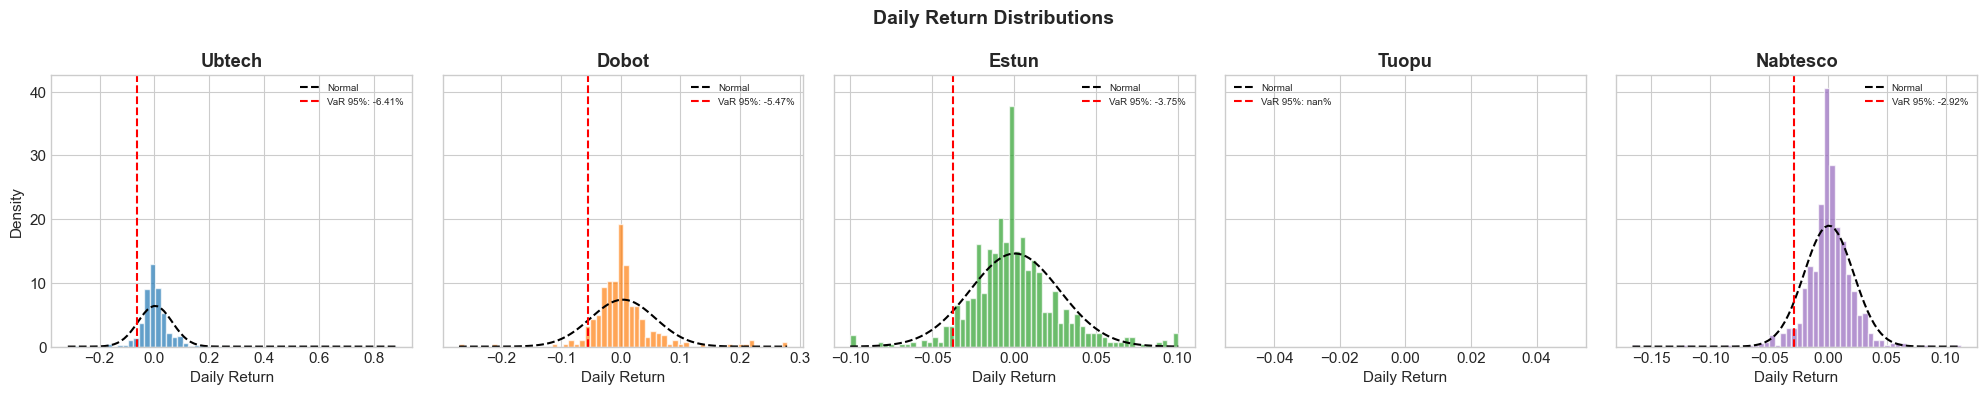

In [12]:
# ============================================================
# 2b. Return Distribution Plots
# ============================================================
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
fig.suptitle('Daily Return Distributions', fontsize=14, fontweight='bold')

for ax, name in zip(axes, COLORS.keys()):
    if name in returns.columns:
        r = returns[name].dropna()
        ax.hist(r, bins=60, density=True, alpha=0.7, color=COLORS[name], edgecolor='white')
        
        # Overlay normal distribution
        x = np.linspace(r.min(), r.max(), 100)
        ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), 'k--', lw=1.5, label='Normal')
        
        # Mark VaR
        var_95 = r.quantile(0.05)
        ax.axvline(var_95, color='red', ls='--', lw=1.5, label=f'VaR 95%: {var_95:.2%}')
        
        ax.set_title(name, fontweight='bold')
        ax.legend(fontsize=7)
        ax.set_xlabel('Daily Return')

axes[0].set_ylabel('Density')
plt.tight_layout()
plt.savefig('return_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

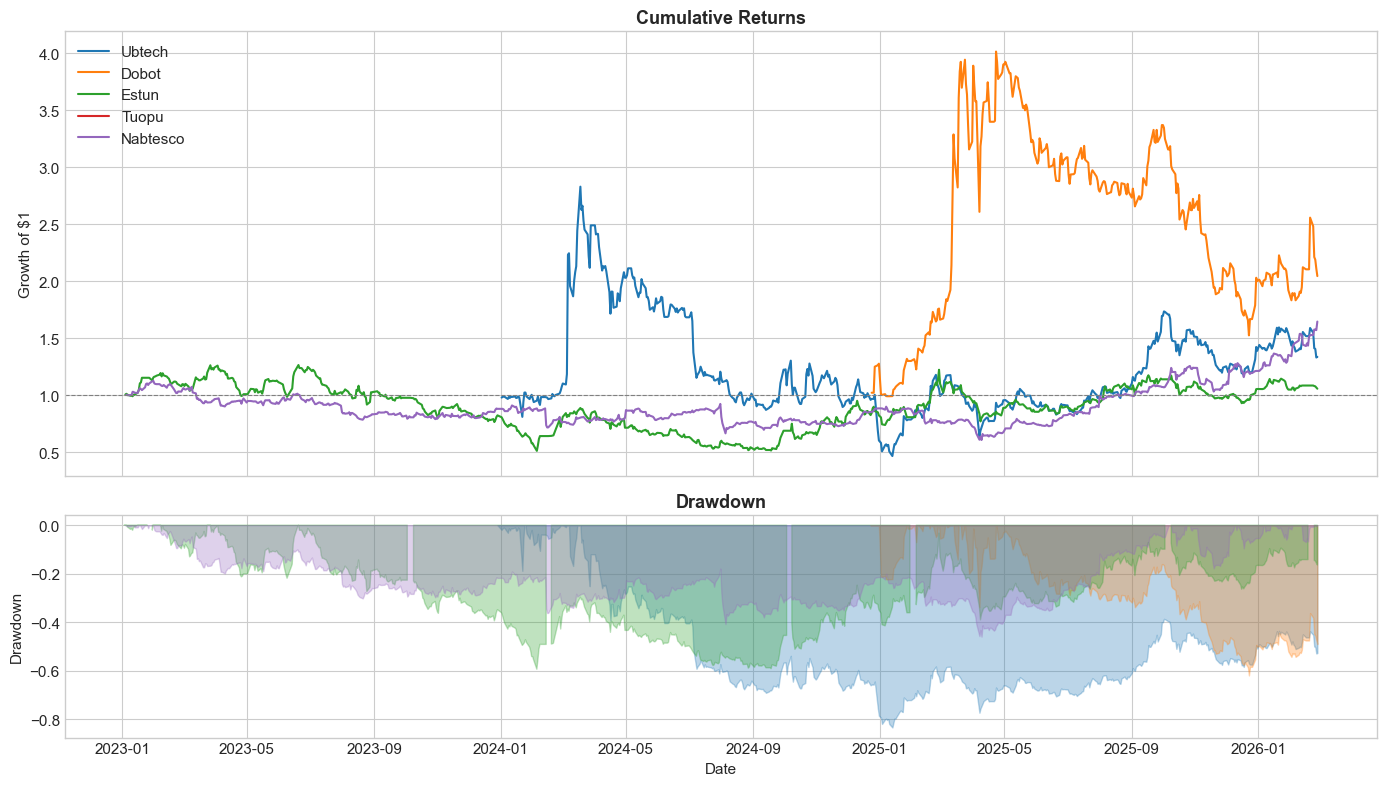

In [13]:
# ============================================================
# 2c. Cumulative Returns & Drawdown
# ============================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

# Cumulative returns
cum_ret = (1 + returns).cumprod()
for name in COLORS:
    if name in cum_ret.columns:
        ax1.plot(cum_ret.index, cum_ret[name], label=name, color=COLORS[name], lw=1.5)
ax1.set_title('Cumulative Returns', fontsize=13, fontweight='bold')
ax1.set_ylabel('Growth of $1')
ax1.legend(loc='upper left')
ax1.axhline(1, color='grey', ls='--', lw=0.8)

# Drawdown
for name in COLORS:
    if name in prices.columns:
        dd = prices[name] / prices[name].cummax() - 1
        ax2.fill_between(dd.index, dd, 0, alpha=0.3, color=COLORS[name], label=name)
ax2.set_title('Drawdown', fontsize=13, fontweight='bold')
ax2.set_ylabel('Drawdown')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.savefig('cumulative_drawdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Factor Decomposition

Decompose each stock's return into:
- **Market beta** (systematic risk)
- **Alpha** (idiosyncratic excess return)
- **R²** (how much is explained by the market)

Using MSCI APAC or a broad China/Japan index as market proxy.

In [14]:
# ============================================================
# 3a. Market Proxy — Download Benchmarks
# ============================================================
# For China stocks: CSI 300 (000300.SS) or MSCI China
# For Japan: Nikkei 225 (^N225)
# Overall: MSCI APAC proxy via iShares (AAXJ)

benchmarks = yf.download(
    ['000300.SS', '^N225'],
    start=prices.index[0],
    end=prices.index[-1],
    auto_adjust=True
)['Close']

benchmarks.columns = ['CSI300', 'Nikkei225']
bench_ret = benchmarks.pct_change().dropna()

# Assign benchmark per stock
BENCH_MAP = {
    'Ubtech': 'CSI300',
    'Dobot': 'CSI300',
    'Estun': 'CSI300',
    'Tuopu': 'CSI300',
    'Nabtesco': 'Nikkei225'
}

print("Benchmark return series loaded.")
bench_ret.describe().round(4)

[*********************100%***********************]  2 of 2 completed

Benchmark return series loaded.


,CSI300,Nikkei225
count,811.0000,811.0000
mean,0.0003,0.0011
std,0.0103,0.0138
min,-0.0705,-0.1240
25%,-0.0051,-0.0053
50%,0.0000,0.0006
75%,0.0048,0.0081
max,0.0848,0.1023


⚠️ Tuopu: only 0 overlapping days, skipping.


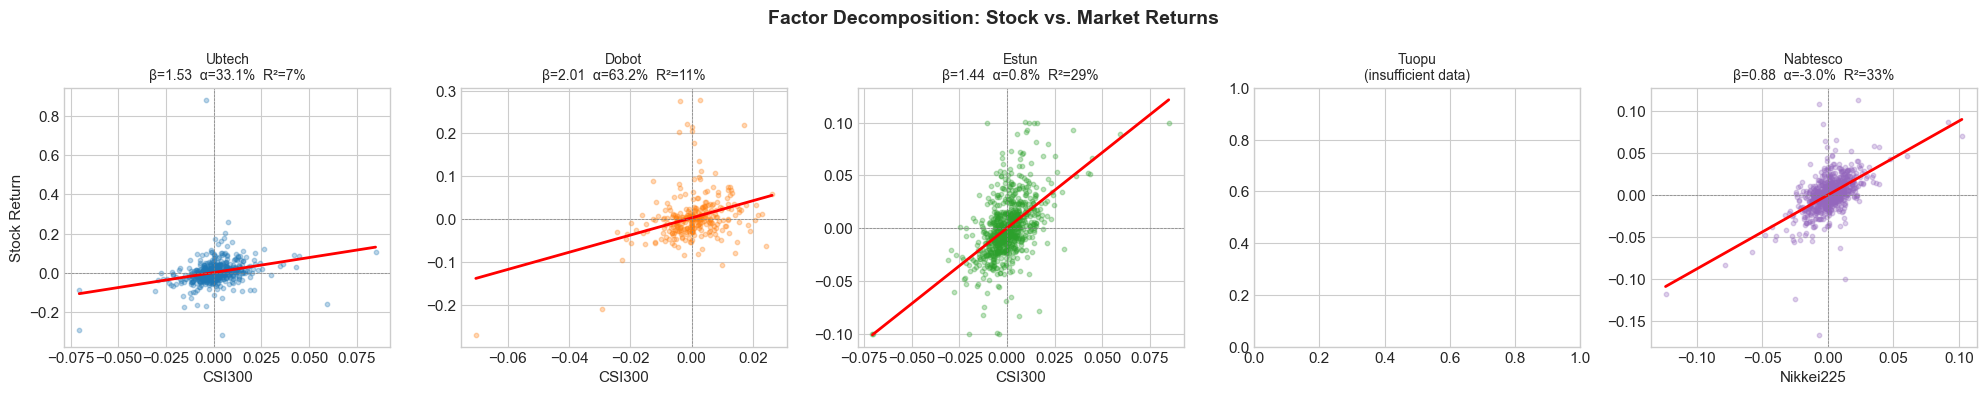

FACTOR DECOMPOSITION SUMMARY


,Ubtech,Dobot,Estun,Tuopu,Nabtesco
Alpha (ann.),33.1%,63.2%,0.8%,N/A,-3.0%
Beta,1.53,2.01,1.44,N/A,0.88
R²,7.31%,11.32%,29.12%,N/A,32.91%
Idio. Vol (ann.),95.4%,80.9%,36.5%,N/A,27.3%
Benchmark,CSI300,CSI300,CSI300,CSI300,Nikkei225


In [16]:
# ============================================================
# 3b. Single-Factor Regression (CAPM-style) — 수정
# ============================================================
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant

factor_results = {}

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Factor Decomposition: Stock vs. Market Returns', fontsize=14, fontweight='bold')

for ax, name in zip(axes, COLORS.keys()):
    if name not in returns.columns:
        ax.set_visible(False)
        continue
    
    bench_name = BENCH_MAP[name]
    
    # Align dates — reindex to stock dates, forward-fill bench up to 3 days
    stock_ret = returns[name].dropna()
    bench_aligned = bench_ret[bench_name].reindex(stock_ret.index, method='ffill', limit=3)
    
    merged = pd.concat([stock_ret, bench_aligned], axis=1, keys=['stock', 'market']).dropna()
    
    # Skip if too few observations
    if len(merged) < 30:
        print(f"⚠️ {name}: only {len(merged)} overlapping days, skipping.")
        ax.set_title(f"{name}\n(insufficient data)", fontsize=10)
        factor_results[name] = {
            'Alpha (ann.)': 'N/A', 'Beta': 'N/A', 'R²': 'N/A',
            'Idio. Vol (ann.)': 'N/A', 'Benchmark': bench_name,
            'alpha_raw': 0, 'beta_raw': 1, 'r2_raw': 0
        }
        continue
    
    # OLS regression
    X = add_constant(merged['market'].values)
    y = merged['stock'].values
    model = OLS(y, X).fit()
    
    alpha_ann = model.params[0] * 252
    beta = model.params[1]
    r_sq = model.rsquared
    idio_vol = model.resid.std() * np.sqrt(252)
    
    factor_results[name] = {
        'Alpha (ann.)': f"{alpha_ann:.1%}",
        'Beta': f"{beta:.2f}",
        'R²': f"{r_sq:.2%}",
        'Idio. Vol (ann.)': f"{idio_vol:.1%}",
        'Benchmark': bench_name,
        'alpha_raw': alpha_ann,
        'beta_raw': beta,
        'r2_raw': r_sq
    }
    
    # Scatter plot
    ax.scatter(merged['market'], merged['stock'], alpha=0.3, s=10, color=COLORS[name])
    x_line = np.linspace(merged['market'].min(), merged['market'].max(), 100)
    ax.plot(x_line, model.params[0] + beta * x_line, 'r-', lw=2)
    ax.set_title(f"{name}\nβ={beta:.2f}  α={alpha_ann:.1%}  R²={r_sq:.0%}", fontsize=10)
    ax.set_xlabel(bench_name)
    ax.axhline(0, color='grey', ls='--', lw=0.5)
    ax.axvline(0, color='grey', ls='--', lw=0.5)

axes[0].set_ylabel('Stock Return')
plt.tight_layout()
plt.savefig('factor_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

factor_df = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk not in ['alpha_raw','beta_raw','r2_raw']} 
                           for k, v in factor_results.items()})
print("="*70)
print("FACTOR DECOMPOSITION SUMMARY")
print("="*70)
factor_df

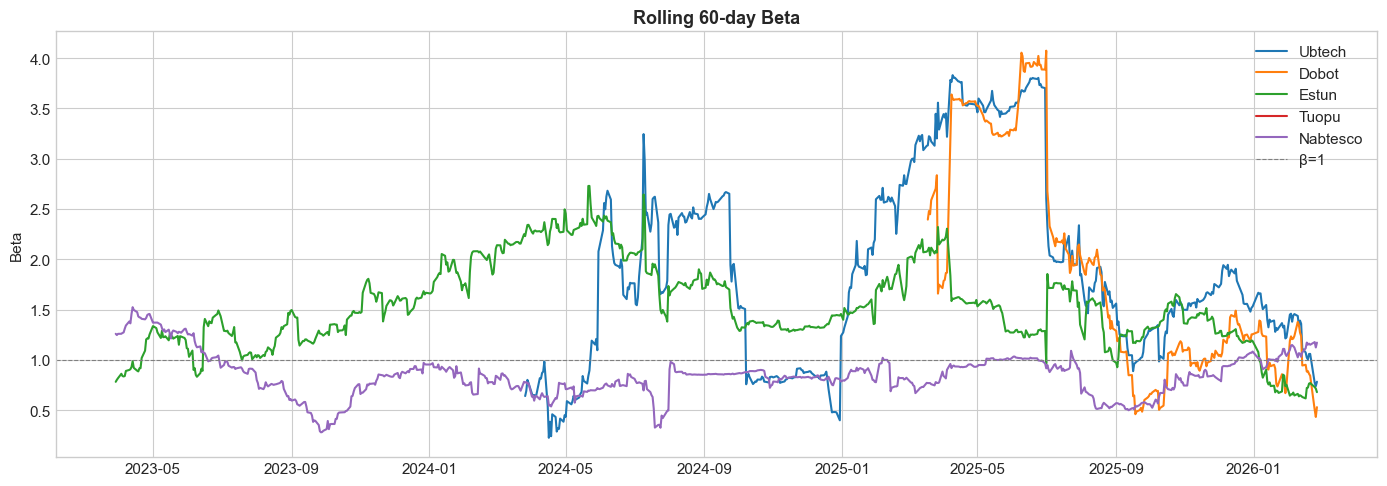

In [17]:
# ============================================================
# 3c. Rolling Beta (60-day window)
# ============================================================
WINDOW = 60

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title(f'Rolling {WINDOW}-day Beta', fontsize=13, fontweight='bold')

for name in COLORS:
    if name not in returns.columns:
        continue
    bench_name = BENCH_MAP[name]
    merged = pd.concat([returns[name], bench_ret[bench_name]], axis=1, join='inner').dropna()
    merged.columns = ['stock', 'market']
    
    rolling_cov = merged['stock'].rolling(WINDOW).cov(merged['market'])
    rolling_var = merged['market'].rolling(WINDOW).var()
    rolling_beta = rolling_cov / rolling_var
    
    ax.plot(rolling_beta.index, rolling_beta, label=name, color=COLORS[name], lw=1.5)

ax.axhline(1, color='grey', ls='--', lw=0.8, label='β=1')
ax.set_ylabel('Beta')
ax.legend()
plt.tight_layout()
plt.savefig('rolling_beta.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. GARCH & Asymmetric Volatility

Fit **EGARCH(1,1)** to capture the leverage effect:  
"Does volatility increase more after a drop than after a rise of the same magnitude?"

In [18]:
# ============================================================
# 4a. EGARCH(1,1) Estimation
# ============================================================
from arch import arch_model

garch_results = {}

fig, axes = plt.subplots(5, 1, figsize=(14, 16), sharex=True)
fig.suptitle('EGARCH(1,1) — Conditional Volatility', fontsize=14, fontweight='bold')

for ax, name in zip(axes, COLORS.keys()):
    if name not in returns.columns:
        continue
    
    r = returns[name].dropna() * 100  # scale to percentage
    
    # Fit EGARCH(1,1)
    model = arch_model(r, vol='EGARCH', p=1, o=1, q=1, dist='skewt', mean='AR', lags=1)
    res = model.fit(disp='off')
    
    # Extract parameters
    omega = res.params.get('omega', np.nan)
    alpha = res.params.get('alpha[1]', np.nan)
    gamma = res.params.get('gamma[1]', np.nan)  # leverage/asymmetry
    beta_g = res.params.get('beta[1]', np.nan)
    
    # Conditional vol (annualized)
    cond_vol = res.conditional_volatility / 100 * np.sqrt(252)
    
    garch_results[name] = {
        'omega': f"{omega:.4f}",
        'alpha (ARCH)': f"{alpha:.4f}",
        'gamma (leverage)': f"{gamma:.4f}",
        'beta (GARCH)': f"{beta_g:.4f}",
        'Avg Cond. Vol (ann.)': f"{cond_vol.mean():.1%}",
        'Vol-of-Vol': f"{cond_vol.std():.1%}",
        'AIC': f"{res.aic:.0f}",
        'Leverage Interpretation': 'Negative → vol rises more on drops' if gamma < 0 else 'Positive → unusual (vol rises more on gains)'
    }
    
    # Plot
    ax.plot(cond_vol.index, cond_vol, color=COLORS[name], lw=1)
    ax.fill_between(cond_vol.index, 0, cond_vol, alpha=0.2, color=COLORS[name])
    ax.set_ylabel('Ann. Vol')
    ax.set_title(f"{name} — γ={gamma:.3f} ({'↑vol on drops' if gamma < 0 else 'symmetric'})",
                 fontsize=11, loc='left')

plt.tight_layout()
plt.savefig('egarch_volatility.png', dpi=150, bbox_inches='tight')
plt.show()

garch_df = pd.DataFrame(garch_results)
print("="*70)
print("EGARCH(1,1) SUMMARY")
print("="*70)
garch_df

ModuleNotFoundError: No module named 'arch'

In [ ]:
# ============================================================
# 4b. News Impact Curve (Asymmetric Response Visualization)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_title('News Impact Curve — Volatility Response to Shocks', fontsize=13, fontweight='bold')

shocks = np.linspace(-3, 3, 200)  # standardized shocks

for name in COLORS:
    if name not in returns.columns:
        continue
    r = returns[name].dropna() * 100
    model = arch_model(r, vol='EGARCH', p=1, o=1, q=1, dist='skewt', mean='AR', lags=1)
    res = model.fit(disp='off')
    
    alpha = res.params.get('alpha[1]', 0)
    gamma = res.params.get('gamma[1]', 0)
    
    # EGARCH news impact: alpha * |z| + gamma * z
    impact = alpha * np.abs(shocks) + gamma * shocks
    ax.plot(shocks, impact, label=name, color=COLORS[name], lw=2)

ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.axvline(0, color='grey', ls='--', lw=0.8)
ax.set_xlabel('Standardized Shock (z)', fontsize=11)
ax.set_ylabel('Log-Variance Impact', fontsize=11)
ax.legend()
ax.annotate('← Bad news', xy=(-2.5, 0), fontsize=9, color='red', ha='center')
ax.annotate('Good news →', xy=(2.5, 0), fontsize=9, color='green', ha='center')

plt.tight_layout()
plt.savefig('news_impact_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-Correlation Structure

In [ ]:
# ============================================================
# 5a. Static Correlation Matrix
# ============================================================
corr_matrix = returns.corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Return Correlation Matrix (Full Sample)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCorrelation matrix:")
corr_matrix.round(3)

In [ ]:
# ============================================================
# 5b. Rolling Correlation (60-day window)
# ============================================================
WINDOW = 60
# Pick Estun as anchor and plot rolling corr with each other stock
anchor = 'Estun'

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_title(f'Rolling {WINDOW}-day Correlation with {anchor}', fontsize=13, fontweight='bold')

for name in COLORS:
    if name == anchor or name not in returns.columns:
        continue
    rolling_corr = returns[anchor].rolling(WINDOW).corr(returns[name])
    ax.plot(rolling_corr.index, rolling_corr, label=name, color=COLORS[name], lw=1.5)

ax.axhline(0, color='grey', ls='--', lw=0.8)
ax.set_ylabel('Correlation')
ax.set_ylim(-0.5, 1)
ax.legend()
plt.tight_layout()
plt.savefig('rolling_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# 5c. Principal Component Analysis — Shared vs. Idiosyncratic
# ============================================================
from sklearn.decomposition import PCA

# Drop NaN rows for PCA
ret_clean = returns.dropna()

pca = PCA()
pca.fit(ret_clean)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Explained variance
ax1.bar(range(1, len(pca.explained_variance_ratio_)+1), 
        pca.explained_variance_ratio_ * 100, color='#2B4C3F', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Variance Explained (%)')
ax1.set_title('PCA — Variance Explained', fontweight='bold')
for i, v in enumerate(pca.explained_variance_ratio_):
    ax1.text(i+1, v*100+0.5, f'{v:.1%}', ha='center', fontsize=10)

# Loadings heatmap (PC1 & PC2)
loadings = pd.DataFrame(
    pca.components_[:3].T,
    columns=['PC1 (Market)', 'PC2', 'PC3'],
    index=ret_clean.columns
)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdYlBu_r', center=0, ax=ax2)
ax2.set_title('PCA Loadings', fontweight='bold')

plt.tight_layout()
plt.savefig('pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

pc1_share = pca.explained_variance_ratio_[0]
print(f"\nPC1 explains {pc1_share:.1%} of total variance.")
print(f"→ If high (>50%): stocks move together (sector beta dominates).")
print(f"→ If low (<30%): idiosyncratic drivers matter more (stock-picking opportunity).")

## 6. Event Study

Compute **Cumulative Abnormal Return (CAR)** around key events.  
Edit the event dates below to match actual earnings/policy dates.

In [ ]:
# ============================================================
# 6a. Define Events (edit dates as needed)
# ============================================================
EVENTS = {
    'Estun': [
        ('2025-03-31', 'Q1 2025 Earnings'),
        ('2025-08-28', 'H1 2025 Earnings'),
        ('2025-06-27', 'HK IPO Application Filed'),
        ('2025-09-15', 'US Section 232 Investigation'),  # approx date
        ('2026-02-23', 'HK IPO Hearing Passed'),
    ],
    'Ubtech': [
        ('2025-03-28', 'FY2024 Earnings'),
        ('2025-08-22', 'H1 2025 Earnings'),
    ],
    'Nabtesco': [
        ('2025-02-14', 'FY2024 Earnings'),
        ('2025-05-15', 'Q1 2025 Earnings'),
        ('2025-08-08', 'H1 2025 Earnings'),
    ],
    # Add Dobot and Tuopu events as needed
}

print("Events defined. Modify dates above if needed.")
for name, events in EVENTS.items():
    print(f"\n{name}:")
    for date, desc in events:
        print(f"  {date} — {desc}")

In [ ]:
# ============================================================
# 6b. Compute CAR (Cumulative Abnormal Return)
# ============================================================
def compute_car(stock_ret, bench_ret_series, event_date, window=(-5, 10)):
    """
    Compute CAR around an event date.
    window: (pre_days, post_days) relative to event.
    Abnormal return = stock return - benchmark return.
    """
    event_dt = pd.Timestamp(event_date)
    
    # Find nearest trading date
    valid_dates = stock_ret.index[stock_ret.index >= event_dt - timedelta(days=10)]
    if len(valid_dates) == 0:
        return None
    
    nearest = valid_dates[0]
    idx = stock_ret.index.get_loc(nearest)
    
    start = max(0, idx + window[0])
    end = min(len(stock_ret) - 1, idx + window[1])
    
    s = stock_ret.iloc[start:end+1]
    b = bench_ret_series.reindex(s.index).fillna(0)
    
    ar = s - b  # abnormal return
    car = ar.cumsum()
    
    # Re-index to relative days
    relative_days = list(range(window[0], window[0] + len(car)))
    car.index = relative_days[:len(car)]
    
    return car


# Plot CAR for Estun events
if 'Estun' in EVENTS and 'Estun' in returns.columns:
    fig, axes = plt.subplots(1, len(EVENTS['Estun']), figsize=(4*len(EVENTS['Estun']), 4))
    if len(EVENTS['Estun']) == 1:
        axes = [axes]
    
    fig.suptitle('Estun — Cumulative Abnormal Return (CAR) Around Events', 
                 fontsize=13, fontweight='bold')
    
    bench_name = BENCH_MAP['Estun']
    
    for ax, (date, desc) in zip(axes, EVENTS['Estun']):
        car = compute_car(returns['Estun'], bench_ret[bench_name], date)
        if car is not None:
            ax.bar(car.index, car * 100, color=[COLORS['Estun'] if v >= 0 else '#d62728' for v in car],
                   alpha=0.7)
            ax.axhline(0, color='grey', ls='--', lw=0.8)
            ax.axvline(0, color='black', ls='-', lw=1.5, label='Event')
            ax.set_title(f"{desc}\n{date}", fontsize=9)
            ax.set_xlabel('Days from Event')
            ax.set_ylabel('CAR (%)')
    
    plt.tight_layout()
    plt.savefig('event_study_estun.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Summary Comparison Table

All key metrics side-by-side for stock selection decision.

In [ ]:
# ============================================================
# 7. Final Comparison Dashboard
# ============================================================

summary = {}

for name in COLORS:
    if name not in returns.columns:
        continue
    
    r = returns[name].dropna()
    
    # Basic stats
    ann_ret = r.mean() * 252
    ann_vol = r.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else np.nan
    max_dd = (prices[name] / prices[name].cummax() - 1).min()
    var_95 = r.quantile(0.05)
    cvar_95 = r[r <= var_95].mean()
    
    # Down/Up vol
    down_vol = r[r < 0].std() * np.sqrt(252)
    up_vol = r[r > 0].std() * np.sqrt(252)
    
    # Factor (from earlier results)
    fr = factor_results.get(name, {})
    
    summary[name] = {
        '--- Return ---': '',
        'Ann. Return': f"{ann_ret:.1%}",
        'Ann. Volatility': f"{ann_vol:.1%}",
        'Sharpe': f"{sharpe:.2f}",
        'Max Drawdown': f"{max_dd:.1%}",
        '--- Tail Risk ---': '',
        'VaR 95%': f"{var_95:.2%}",
        'CVaR 95%': f"{cvar_95:.2%}",
        'Down/Up Vol': f"{(down_vol/up_vol):.2f}",
        'Skewness': f"{r.skew():.2f}",
        'Excess Kurtosis': f"{r.kurtosis():.2f}",
        '--- Factor ---': '',
        'Beta': fr.get('Beta', 'N/A'),
        'Alpha (ann.)': fr.get('Alpha (ann.)', 'N/A'),
        'R²': fr.get('R²', 'N/A'),
        'Idio. Vol': fr.get('Idio. Vol (ann.)', 'N/A'),
        '--- EGARCH ---': '',
        'Leverage (γ)': garch_results.get(name, {}).get('gamma (leverage)', 'N/A'),
        'Avg Cond. Vol': garch_results.get(name, {}).get('Avg Cond. Vol (ann.)', 'N/A'),
    }

summary_df = pd.DataFrame(summary)
print("="*80)
print("FINAL COMPARISON — STOCK SELECTION DASHBOARD")
print("="*80)
summary_df

In [ ]:
# ============================================================
# 7b. Radar Chart — Visual Comparison
# ============================================================
from math import pi

# Normalize key metrics to 0-1 scale for radar
radar_metrics = {}
for name in COLORS:
    if name not in returns.columns:
        continue
    r = returns[name].dropna()
    fr = factor_results.get(name, {})
    
    radar_metrics[name] = {
        'Return': r.mean() * 252,
        'Sharpe': r.mean() * 252 / (r.std() * np.sqrt(252)) if r.std() > 0 else 0,
        'Low Tail Risk': -r.quantile(0.05),  # flip sign so higher = better
        'Alpha': fr.get('alpha_raw', 0),
        'Low Beta': 2 - fr.get('beta_raw', 1),  # flip: lower beta = higher score
    }

radar_df = pd.DataFrame(radar_metrics).T

# Min-max normalize
for col in radar_df.columns:
    mn, mx = radar_df[col].min(), radar_df[col].max()
    if mx > mn:
        radar_df[col] = (radar_df[col] - mn) / (mx - mn)
    else:
        radar_df[col] = 0.5

# Plot
categories = list(radar_df.columns)
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_title('Stock Comparison Radar', fontsize=14, fontweight='bold', pad=20)

for name in radar_df.index:
    values = radar_df.loc[name].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', lw=2, label=name, color=COLORS[name])
    ax.fill(angles, values, alpha=0.1, color=COLORS[name])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Interpretation Guide

### For Stock Selection:

| What to look for | Why it matters for the pitch |
|---|---|
| **Positive alpha + Low R²** | Stock has idiosyncratic driver, not just riding sector beta |
| **Negative gamma (EGARCH)** | Vol spikes more on drops → bigger downside risk than raw vol suggests |
| **Low correlation with peers** | Independent catalyst → stronger conviction argument |
| **Fat left tail (high kurtosis, neg skew)** | VaR understates true risk; use CVaR in pitch |
| **Positive CAR post-earnings** | Market systematically underprices good news → potential alpha |
| **PC1 loading outlier** | If one stock loads differently on PC1, it has unique drivers |

### Suggested Pitch Framing:
- **Long thesis**: High alpha, improving vol regime, positive event CAR, low correlation
- **Short thesis**: Negative alpha, high leverage gamma, deteriorating CAR, high beta + R²

In [5]:
"""
WACC Peer Beta Calculator — MSCI World Benchmark (USD-adjusted)
===============================================================
각 주식 수익률을 USD로 환산한 뒤 URTH(MSCI World proxy) 대비 OLS 회귀
기간: 5년 월별 (2021-01 ~ 2025-12)
"""

import pandas as pd
import numpy as np
from scipy import stats
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")

# ─────────────────────────────────────────
# 1. PEER DEFINITIONS
# ─────────────────────────────────────────
PEERS = [
    {"name": "Harmonic Drive Systems",    "yf_ticker": "6324.T",    "fx_ticker": "JPYUSD=X"},
    {"name": "Sumitomo Heavy Industries", "yf_ticker": "6302.T",    "fx_ticker": "JPYUSD=X"},
    {"name": "THK",                       "yf_ticker": "6481.T",    "fx_ticker": "JPYUSD=X"},
    {"name": "Nidec Corp",                "yf_ticker": "6594.T",    "fx_ticker": "JPYUSD=X"},
    {"name": "Apex Dynamics",             "yf_ticker": "1590.TW",   "fx_ticker": "TWDUSD=X"},
    {"name": "Leaderdrive",               "yf_ticker": "688017.SS", "fx_ticker": "CNYUSD=X"},
    {"name": "Zhejiang Shuanghuan",       "yf_ticker": "002472.SZ", "fx_ticker": "CNYUSD=X"},
]

START = "2020-12-01"
END   = "2025-12-31"

# ─────────────────────────────────────────
# 2. FETCH MSCI WORLD (URTH ETF) — already USD
# ─────────────────────────────────────────
print("Fetching MSCI World proxy (URTH ETF)...")
urth = yf.download("URTH", start=START, end=END, interval="1mo",
                   auto_adjust=True, progress=False)
msci = urth["Close"].squeeze().pct_change().dropna()
msci.index = msci.index.to_period("M").to_timestamp("M")
msci.name = "msci_world"
print(f"MSCI World: {len(msci)} obs ({msci.index[0].date()} ~ {msci.index[-1].date()})\n")

# ─────────────────────────────────────────
# 3. FX CACHE — fetch each FX pair once
# ─────────────────────────────────────────
fx_cache = {}

def get_fx_returns(fx_ticker):
    if fx_ticker in fx_cache:
        return fx_cache[fx_ticker]
    raw = yf.download(fx_ticker, start=START, end=END, interval="1mo",
                      auto_adjust=True, progress=False)
    if raw.empty:
        fx_cache[fx_ticker] = None
        return None
    prices = raw["Close"].squeeze()
    ret = prices.pct_change().dropna()
    ret.index = ret.index.to_period("M").to_timestamp("M")
    fx_cache[fx_ticker] = ret
    return ret

# ─────────────────────────────────────────
# 4. USD-CONVERTED RETURN
#    r_usd ≈ r_local + r_fx  (log approximation, sufficient for monthly)
# ─────────────────────────────────────────
def to_usd_return(local_ret, fx_ret):
    df = pd.concat([local_ret, fx_ret], axis=1).dropna()
    df.columns = ["local", "fx"]
    usd_ret = (1 + df["local"]) * (1 + df["fx"]) - 1
    return usd_ret

# ─────────────────────────────────────────
# 5. OLS BETA
# ─────────────────────────────────────────
def calc_beta(stock_ret, market_ret):
    df = pd.concat([stock_ret, market_ret], axis=1).dropna()
    df.columns = ["stock", "market"]
    slope, _, r, p, _ = stats.linregress(df["market"], df["stock"])
    return round(slope, 4), round(r**2, 4), len(df)

# ─────────────────────────────────────────
# 6. MAIN LOOP
# ─────────────────────────────────────────
results = []

for peer in PEERS:
    name      = peer["name"]
    ticker    = peer["yf_ticker"]
    fx_ticker = peer["fx_ticker"]
    print(f"{'─'*50}")
    print(f"{name} ({ticker})")

    # 주가
    raw = yf.download(ticker, start=START, end=END, interval="1mo",
                      auto_adjust=True, progress=False)
    if raw.empty:
        print(f"  ⚠️  주가 데이터 없음. 스킵.")
        results.append({"name": name, "ticker": ticker,
                        "levered_beta": None, "r_squared": None, "n_obs": None, "note": "No data"})
        continue

    local_ret = raw["Close"].squeeze().pct_change().dropna()
    local_ret.index = local_ret.index.to_period("M").to_timestamp("M")

    # 환율
    fx_ret = get_fx_returns(fx_ticker)
    if fx_ret is None:
        print(f"  ⚠️  FX 데이터 없음. 스킵.")
        results.append({"name": name, "ticker": ticker,
                        "levered_beta": None, "r_squared": None, "n_obs": None, "note": "No FX data"})
        continue

    # USD 환산
    usd_ret = to_usd_return(local_ret, fx_ret)
    print(f"  관측치: {len(usd_ret)}개  ({usd_ret.index[0].date()} ~ {usd_ret.index[-1].date()})")

    beta, r2, n = calc_beta(usd_ret, msci)
    print(f"  Levered Beta (vs MSCI World, USD): {beta}  R²={r2}  n={n}")

    results.append({
        "name":         name,
        "ticker":       ticker,
        "levered_beta": beta,
        "r_squared":    r2,
        "n_obs":        n,
        "note":         "OK",
    })

# ─────────────────────────────────────────
# 7. SUMMARY
# ─────────────────────────────────────────
print("\n" + "═"*60)
print("SUMMARY — Levered Beta vs MSCI World, USD-adjusted (5Y Monthly)")
print("═"*60)
df_out = pd.DataFrame(results)
print(df_out[["name", "ticker", "levered_beta", "r_squared", "n_obs", "note"]].to_string(index=False))

df_out.to_csv("peer_betas_msci_world_usd.csv", index=False)
print("\n→ peer_betas_msci_world_usd.csv 저장 완료")
print("\n⚠️  Wittenstein: 비상장(GmbH) → Damodaran 'Machinery (Global)' Unlevered Beta 사용 권장")

Fetching MSCI World proxy (URTH ETF)...
MSCI World: 60 obs (2021-01-31 ~ 2025-12-31)

──────────────────────────────────────────────────
Harmonic Drive Systems (6324.T)
  관측치: 60개  (2021-01-31 ~ 2025-12-31)
  Levered Beta (vs MSCI World, USD): 0.633  R²=0.0244  n=60
──────────────────────────────────────────────────
Sumitomo Heavy Industries (6302.T)
  관측치: 60개  (2021-01-31 ~ 2025-12-31)
  Levered Beta (vs MSCI World, USD): 0.7561  R²=0.2189  n=60
──────────────────────────────────────────────────
THK (6481.T)
  관측치: 60개  (2021-01-31 ~ 2025-12-31)
  Levered Beta (vs MSCI World, USD): 0.9798  R²=0.212  n=60
──────────────────────────────────────────────────
Nidec Corp (6594.T)
  관측치: 60개  (2021-01-31 ~ 2025-12-31)
  Levered Beta (vs MSCI World, USD): 1.0367  R²=0.216  n=60
──────────────────────────────────────────────────
Apex Dynamics (1590.TW)
  관측치: 60개  (2021-01-31 ~ 2025-12-31)
  Levered Beta (vs MSCI World, USD): 0.4717  R²=0.0321  n=60
───────────────────────────────────────────

In [6]:
import yfinance as yf
import numpy as np

# Levered betas from prior session (OLS regression vs URTH)
levered_betas = {
    "6324.T":    0.6330,
    "6302.T":    0.7561,
    "6481.T":    0.9798,
    "6594.T":    1.0367,
    "1590.TW":   0.4717,
    "688017.SS": 1.0258,
    "002472.SZ": 0.8539,
}

# Statutory tax rates by country
tax_rates = {
    "6324.T":    0.3062,  # Japan
    "6302.T":    0.3062,  # Japan
    "6481.T":    0.3062,  # Japan
    "6594.T":    0.3062,  # Japan
    "1590.TW":   0.20,    # Taiwan
    "688017.SS": 0.25,    # China
    "002472.SZ": 0.25,    # China
}

names = {
    "6324.T":    "Harmonic Drive",
    "6302.T":    "Sumitomo Heavy",
    "6481.T":    "THK",
    "6594.T":    "Nidec",
    "1590.TW":   "Apex Dynamics",
    "688017.SS": "Leaderdrive",
    "002472.SZ": "Zhejiang Shuanghuan",
}

print(f"{'Company':<25} {'Ticker':<12} {'Total Debt (B)':>14} {'Mkt Cap (B)':>12} {'D/E':>8} {'Tax':>6} {'Unlevered Beta':>15}")
print("-" * 100)

unlevered_betas = []

for ticker, bl in levered_betas.items():
    try:
        info = yf.Ticker(ticker).info
        total_debt = info.get('totalDebt', None)
        mkt_cap = info.get('marketCap', None)

        if not total_debt or not mkt_cap:
            print(f"{names[ticker]:<25} {ticker:<12} {'N/A':>14} {'N/A':>12} {'N/A':>8} {tax_rates[ticker]:>6.1%} {'N/A':>15}")
            continue

        t = tax_rates[ticker]
        de = total_debt / mkt_cap
        bu = bl / (1 + (1 - t) * de)
        unlevered_betas.append(bu)

        print(f"{names[ticker]:<25} {ticker:<12} {total_debt/1e9:>13.2f}B {mkt_cap/1e9:>11.2f}B {de:>8.4f} {t:>6.1%} {bu:>15.4f}")

    except Exception as e:
        print(f"{names[ticker]:<25} {ticker:<12} ERROR: {e}")

# Wittenstein: use Damodaran Global Machinery unlevered beta (hardcoded)
# Source: https://pages.stern.nyu.edu/~adamodar/ -> Betas by Sector (Global) -> Machinery
wittenstein_bu = 0.72  # UPDATE this from Damodaran site before running
print(f"{'Wittenstein':<25} {'비상장':<12} {'Damodaran':>14} {'Machinery':>12} {'N/A':>8} {'N/A':>6} {wittenstein_bu:>15.4f}  <- Damodaran Global Machinery")
unlevered_betas.append(wittenstein_bu)

print()
print(f"Unlevered Betas collected: {[round(b,4) for b in unlevered_betas]}")
print(f"Median Unlevered Beta: {np.median(unlevered_betas):.4f}")
print(f"Mean Unlevered Beta:   {np.mean(unlevered_betas):.4f}")

Company                   Ticker       Total Debt (B)  Mkt Cap (B)      D/E    Tax  Unlevered Beta
----------------------------------------------------------------------------------------------------
Harmonic Drive            6324.T               18.49B      412.27B   0.0448  30.6%          0.6139
Sumitomo Heavy            6302.T              252.70B      677.23B   0.3731  30.6%          0.6006
THK                       6481.T              123.21B      572.10B   0.2154  30.6%          0.8524
Nidec                     6594.T              712.03B     2659.44B   0.2677  30.6%          0.8743
Apex Dynamics             1590.TW               3.24B      218.00B   0.0148  20.0%          0.4662
Leaderdrive               688017.SS             0.03B       39.05B   0.0008  25.0%          1.0252
Zhejiang Shuanghuan       002472.SZ             4.08B       32.71B   0.1248  25.0%          0.7808
Wittenstein               비상장               Damodaran    Machinery      N/A    N/A          0.7200  <- Damo